In [1]:
import numpy as np
import matplotlib.pyplot as plt
cmap = 'tab10'
import pandas as pd


import pickle

import scanpy as sc
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.metrics import rand_score, confusion_matrix

from openTSNE import TSNE
from phate import PHATE
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA
from umap import UMAP

import sys
sys.path.append('../code')
from align import *
from embed import *
from eval import *

In [2]:
import torchvision
import torch
from torchvision import transforms

mnist = torchvision.datasets.MNIST(root = '../../clustering_embedding/mnist/', train = True, download = False,  transform=transforms.Compose([
                                                              transforms.ToTensor()]))

mnist_ims = torch.stack([data for data, _ in mnist])
labels =  np.array([data for _, data in mnist])

In [3]:
pca = PCA(n_components = 50)
mnist = pca.fit_transform(mnist_ims.reshape(60000,-1))
n = mnist.shape[0]

In [4]:

with open('../results/mnist/clusters.pkl', 'rb') as file:
    clusters = pickle.load(file) 

In [5]:

with open('../results/mnist/ce_data.pkl', 'rb') as file:
    temp = pickle.load(file) 
alignment_idxs, distances = temp

In [6]:

with open('../results/mnist/isomap_embeddings.pkl', 'rb') as file:
    ce_1, ce_175 = pickle.load(file) 

In [8]:
#reuse old embeddings
embeddings = np.zeros((n,2))
for i in range(10):
    embeddings[clusters == i,:] = ce_1[clusters== i] - np.mean(ce_1[clusters== i], axis = 0)

In [9]:
embedding_sampled, clusters_sampled = embeddings[alignment_idxs,:], clusters[alignment_idxs]

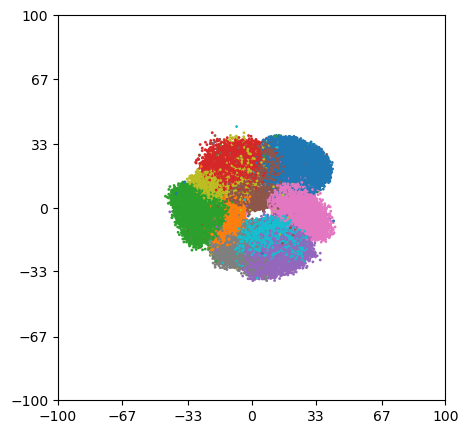

In [10]:
ce_1_, _ = procrustes(ce_175, ce_1)
plt.figure(figsize = [5,5])
plt.scatter(ce_1_[:,0], ce_1_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-100,100)
plt.ylim(-100,100)
plt.xticks(np.round(np.linspace(-100,100,7),0))
plt.yticks(np.round(np.linspace(-100,100,7),0))
plt.savefig('../figures/mnist/alpha1.png', format='png', dpi=300, bbox_inches='tight')

In [17]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =1.25)
ce_125 = out.align_embedding(m = 50 )
ce_125 =  out.embed_points(embeddings,clusters)

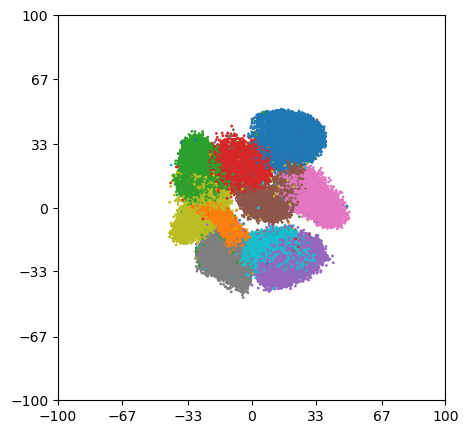

In [20]:
ce_125_, _ = procrustes(ce_175, ce_125)
plt.figure(figsize = [5,5])
plt.scatter(ce_125_[:,0], ce_125_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-100,100)
plt.ylim(-100,100)
plt.xticks(np.round(np.linspace(-100,100,7),0))
plt.yticks(np.round(np.linspace(-100,100,7),0))
plt.savefig('../figures/mnist/alpha125.png', format='png', dpi=300, bbox_inches='tight')

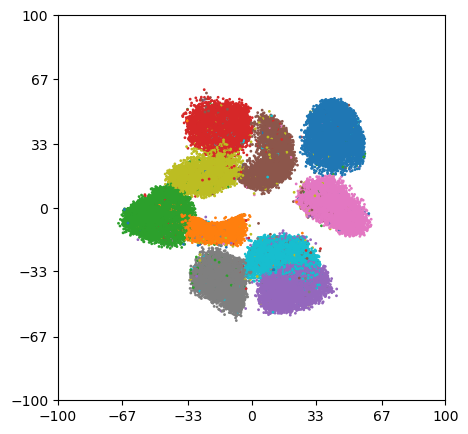

In [19]:
plt.figure(figsize = [5,5])
plt.scatter(ce_175[:,0], ce_175[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-100,100)
plt.ylim(-100,100)
plt.xticks(np.round(np.linspace(-100,100,7),0))
plt.yticks(np.round(np.linspace(-100,100,7),0))
plt.savefig('../figures/mnist/alpha175.png', format='png', dpi=300, bbox_inches='tight')

In [21]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =2.25)
ce_2 = out.align_embedding(m = 50 )
ce_2 =  out.embed_points(embeddings,clusters)

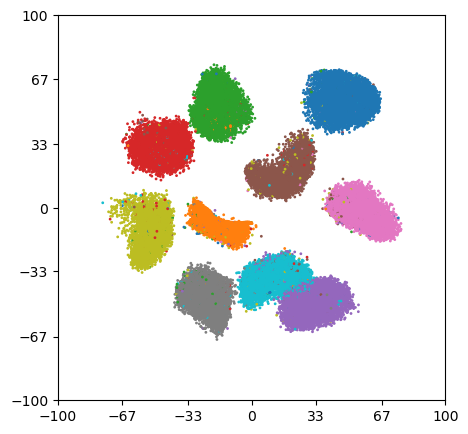

In [24]:
ce_2_, _ = procrustes(ce_175, ce_2)
plt.figure(figsize = [5,5])
plt.scatter(ce_2_[:,0], ce_2_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-100,100)
plt.ylim(-100,100)
plt.xticks(np.round(np.linspace(-100,100,7),0))
plt.yticks(np.round(np.linspace(-100,100,7),0))
plt.savefig('../figures/mnist/alpha225.png', format='png', dpi=300, bbox_inches='tight')

In [25]:
out = Embedding(embedding_sampled, clusters_sampled, distances, alpha =2.75)
ce_275 = out.align_embedding(m = 50 )
ce_275 =  out.embed_points(embeddings,clusters)

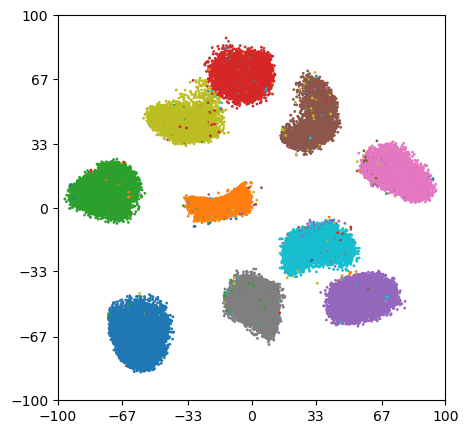

In [28]:
ce_275_, _ = procrustes(ce_175, ce_275)
plt.figure(figsize = [5,5])
plt.scatter(ce_275_[:,0], ce_275_[:,1], c = labels, cmap = 'tab10', s = 1)
plt.xlim(-100,100)
plt.ylim(-100,100)
plt.xticks(np.round(np.linspace(-100,100,7),0))
plt.yticks(np.round(np.linspace(-100,100,7),0))
plt.savefig('../figures/mnist/alpha275.png', format='png', dpi=300, bbox_inches='tight')

In [30]:
with open('../results/mnist/alpha_embs.pkl', 'wb') as file:  
    pickle.dump([ce_1, ce_125, ce_175, ce_2, ce_275], file)

In [31]:
all_embs = [ce_1, ce_125, ce_175, ce_2, ce_275]

In [33]:
geodesic_distances = pd.read_csv("C:/Users/codae/OneDrive/Documents/clustering_embedding_data/MNIST_geodesic_5.csv")
geodesic_distances = squareform(geodesic_distances.to_numpy().flatten())
geodesic_distances.shape

(5000, 5000)

In [34]:
orig_distances = geodesic_distances

for emb in all_embs:
    emb_distances =  squareform(pdist(emb[0:5000]))
    spearman_scores = spearman(orig_distances, emb_distances, labels[0:5000])
    stress_scores = normalized_stress(orig_distances, emb_distances, labels[0:5000])
    class_score = class_preservation(orig_distances, emb_distances, labels[0:5000])
    scaled_stress_scores =  scale_normalized_stress(orig_distances, emb_distances, labels[0:5000])
    recall_score = knn_recall(mnist[0:5000], emb[0:5000], [30])
    
    formatted = " & ".join(
    [
        f"${spearman_scores[0]:.2f}$",
        f"${stress_scores[0]:.2f}$",
        f"${scaled_stress_scores[0]:.2f}$",
        f"${recall_score[0]:.2f}$",
        *[f"${x:.2f}$" for x in spearman_scores[1:]],
        *[f"${x:.2f}$" for x in stress_scores[1:]],
        *[f"${x:.2f}$" for x in scaled_stress_scores[1:]],
        f"${class_score:.2f}$"
    ]
)


    print(formatted)
    print()

$0.81$ & $0.52$ & $0.31$ & $0.26$ & $0.43$ & $0.63$ & $0.35$ & $0.36$ & $0.28$ & $0.34$ & $0.74$

$0.81$ & $0.51$ & $0.35$ & $0.31$ & $0.41$ & $0.62$ & $0.33$ & $0.35$ & $0.26$ & $0.34$ & $0.68$

$0.80$ & $0.53$ & $0.44$ & $0.37$ & $0.42$ & $0.61$ & $0.51$ & $0.58$ & $0.23$ & $0.34$ & $0.73$

$0.80$ & $0.57$ & $0.53$ & $0.38$ & $0.39$ & $0.58$ & $0.80$ & $0.92$ & $0.22$ & $0.35$ & $0.64$

$0.80$ & $0.62$ & $0.59$ & $0.38$ & $0.38$ & $0.52$ & $1.16$ & $1.30$ & $0.21$ & $0.37$ & $0.54$

